# Hospital Treatment Cost Analysis

## Case Study: DAD Hospital

### Objective

This project analyzes the relationship between patient body weight and treatment cost using statistical analysis and simple linear regression.

### Dataset

The dataset contains 120 patient observations with the following variables:

- **Body Weight:** Weight of the patient
- **Treatment Cost:** Cost of treatment

### Research Questions

1. Is there statistical evidence that treatment cost and body weight are related?
2. Comment on the value of R-squared. Does a low R-squared value indicate that the model is not useful?
3. Interpret the coefficient of weight in the regression model.
4. What is the average difference in treatment cost between a patient weighing 50 kg and a patient weighing 51 kg?
5. At a 90% confidence level, is a patient weighing 50 kg likely to spend at least INR 500 more than a patient weighing 49 kg?
6. For a patient weighing 50 kg, calculate the 95% confidence interval for the average treatment cost.
7. If DAD Hospital introduces a package price of INR 300,000 for patients weighing 50 kg, what is the probability that treatment cost exceeds the package price?

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy
- Statsmodels

# Data Preparation and Statistical Analysis

The original dataset was extracted from the Excel file by selecting the relevant variables required for the case study:

- Patient Number
- Body Weight
- Treatment Cost

The analysis below uses the original patient observations to perform statistical analysis and develop a simple linear regression model.

In [1]:
import pandas as pd

# Load the Excel file
file_name = "DAD_Hospital_LogCost_Regression_Analysis (1).xlsx"

# Read the data sheet
raw_data = pd.read_excel(
    file_name,
    sheet_name="Full_Diagnostics"
)

# Show the column names
print(raw_data.columns.tolist())

# Show the first 5 rows
raw_data.head()

['RNo', 'Body Weight', 'Cost', 'ln(Cost)', 'Predicted ln(Cost)', 'Residual', 'Residual Z', 'Mahalanobis D²', 'Mahalanobis D', "Cook's D", 'Leverage', 'DFBeta Intercept', 'DFBeta BodyWeight', 'DFFit', 'Flag Resid Z', 'Flag MD', 'Flag Cook', 'Flag Leverage', 'Flag DFBeta', 'Flag DFFit']


,RNo,Body Weight,Cost,ln(Cost),Predicted ln(Cost),Residual,Residual Z,Mahalanobis D²,Mahalanobis D,Cook's D,Leverage,DFBeta Intercept,DFBeta BodyWeight,DFFit,Flag Resid Z,Flag MD,Flag Cook,Flag Leverage,Flag DFBeta,Flag DFFit
0,1,32,148652.00,11.909363,12.043320,-0.133956,-0.338366,4.373317,2.091248,0.002807,0.045084,-0.072465,0.067390,-0.074640,False,False,False,True,False,False
1,2,32,128104.37,11.760601,12.043320,-0.282719,-0.714132,4.373317,2.091248,0.012501,0.045084,-0.153206,0.142476,-0.157805,False,False,False,True,False,False
2,3,33,133087.00,11.798758,12.050797,-0.252039,-0.636635,4.019830,2.004951,0.009223,0.042113,-0.130977,0.121339,-0.135481,False,False,False,True,False,False
3,4,35,124804.00,11.734500,12.065751,-0.331252,-0.836723,3.357539,1.832359,0.013667,0.036548,-0.157979,0.145090,-0.165132,False,False,False,True,False,False
4,5,36,199790.00,12.205022,12.073229,0.131793,0.332902,3.048734,1.746062,0.001999,0.033953,0.059875,-0.054718,0.062992,False,False,False,True,False,False


DATASET OVERVIEW

Number of observations: 120

First 5 observations:


,Patient_ID,Weight,Cost
0,1,32,148652.00
1,2,32,128104.37
2,3,33,133087.00
3,4,35,124804.00
4,5,36,199790.00



Missing values:
Patient_ID    0
Weight        0
Cost          0
dtype: int64

Descriptive Statistics:


,Patient_ID,Weight,Cost
count,120.000000,120.000000,120.000000
mean,60.500000,56.233333,221910.092667
std,34.785054,11.587978,98065.496352
min,1.000000,32.000000,102537.850000
25%,30.750000,47.000000,144109.807500
50%,60.500000,56.500000,192365.500000
75%,90.250000,64.000000,276030.500000
max,120.000000,78.000000,514524.000000


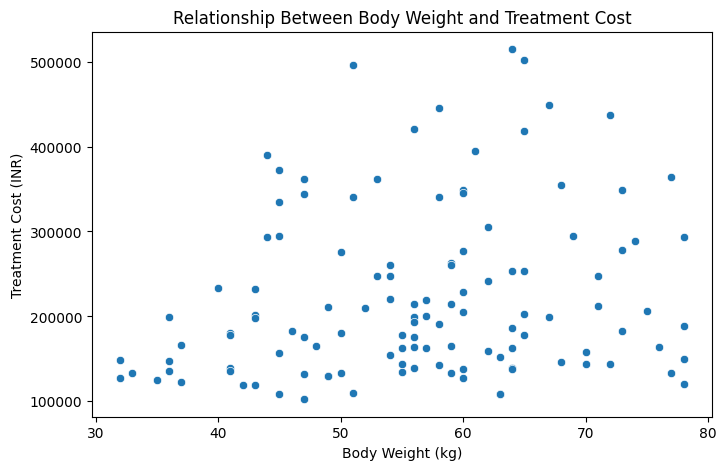

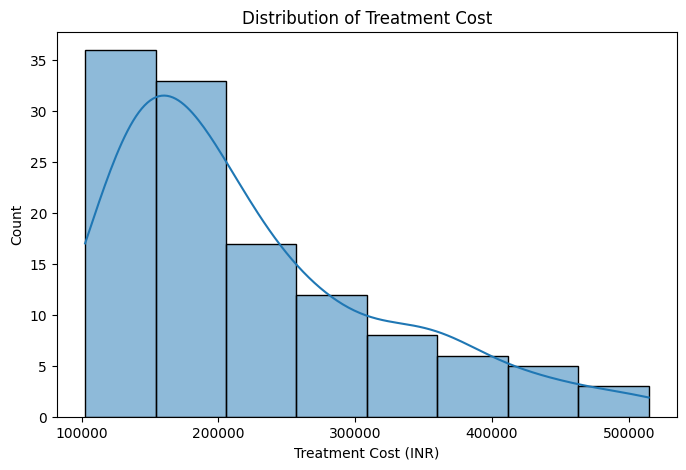


CORRELATION ANALYSIS
Correlation coefficient: 0.1984
P-value: 0.0298

SIMPLE LINEAR REGRESSION MODEL
                            OLS Regression Results                            
Dep. Variable:                   Cost   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     4.835
Date:                Sun, 06 Sep 2026   Prob (F-statistic):             0.0298
Time:                        17:49:31   Log-Likelihood:                -1546.6
No. Observations:                 120   AIC:                             3097.
Df Residuals:                     118   BIC:                             3103.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

In [2]:
# ============================================================
# DAD HOSPITAL - TREATMENT COST ANALYSIS
# Statistical Regression Analysis
# ============================================================

# -------------------------------
# 1. IMPORT LIBRARIES
# -------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy import stats


# -------------------------------
# 2. LOAD AND PREPARE DATA
# -------------------------------

file_name = "DAD_Hospital_LogCost_Regression_Analysis (1).xlsx"

raw_data = pd.read_excel(
    file_name,
    sheet_name="Full_Diagnostics"
)

# Extract only the original raw variables
df = raw_data[["RNo", "Body Weight", "Cost"]].copy()

# Rename columns
df.columns = ["Patient_ID", "Weight", "Cost"]

# Remove missing values if any
df = df.dropna()

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print("\nNumber of observations:", len(df))

print("\nFirst 5 observations:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
display(df.describe())


# ============================================================
# 3. EXPLORATORY DATA ANALYSIS
# ============================================================

# Scatter Plot
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Weight",
    y="Cost"
)

plt.title("Relationship Between Body Weight and Treatment Cost")
plt.xlabel("Body Weight (kg)")
plt.ylabel("Treatment Cost (INR)")

plt.show()


# Cost Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Cost"],
    kde=True
)

plt.title("Distribution of Treatment Cost")
plt.xlabel("Treatment Cost (INR)")

plt.show()


# ============================================================
# 4. CORRELATION ANALYSIS
# ============================================================

correlation, corr_pvalue = stats.pearsonr(
    df["Weight"],
    df["Cost"]
)

print("\n" + "=" * 70)
print("CORRELATION ANALYSIS")
print("=" * 70)

print(f"Correlation coefficient: {correlation:.4f}")
print(f"P-value: {corr_pvalue:.4f}")


# ============================================================
# 5. SIMPLE LINEAR REGRESSION
# ============================================================

# Model:
# Cost = β0 + β1(Weight)

model = smf.ols(
    "Cost ~ Weight",
    data=df
).fit()

print("\n" + "=" * 70)
print("SIMPLE LINEAR REGRESSION MODEL")
print("=" * 70)

print(model.summary())


# ============================================================
# QUESTION 1
# Is there statistical evidence that cost of treatment
# and body weight are related?
# ============================================================

print("\n" + "=" * 70)
print("QUESTION 1")
print("=" * 70)

p_value_weight = model.pvalues["Weight"]

print("Hypothesis:")
print("H0: Body weight has no relationship with treatment cost.")
print("H1: Body weight is related to treatment cost.")

print(f"\nP-value for body weight: {p_value_weight:.4f}")

if p_value_weight < 0.05:
    print("\nConclusion:")
    print(
        "Reject H0. There is statistically significant evidence "
        "that body weight and treatment cost are related."
    )
else:
    print("\nConclusion:")
    print(
        "Fail to reject H0. There is insufficient statistical evidence "
        "that body weight and treatment cost are related."
    )


# ============================================================
# QUESTION 2
# Comment on the R-Squared value
# ============================================================

print("\n" + "=" * 70)
print("QUESTION 2")
print("=" * 70)

r_squared = model.rsquared

print(f"R-squared: {r_squared:.4f}")
print(
    f"\nInterpretation: Approximately "
    f"{r_squared * 100:.2f}% of the variation in treatment cost "
    f"is explained by differences in patient body weight."
)

if r_squared < 0.10:
    print(
        "\nThe model has low explanatory power, meaning body weight "
        "alone is not sufficient to accurately predict treatment cost."
    )


# ============================================================
# QUESTION 3
# Interpret the coefficient of weight
# ============================================================

print("\n" + "=" * 70)
print("QUESTION 3")
print("=" * 70)

weight_coefficient = model.params["Weight"]

print(f"Regression coefficient for weight: {weight_coefficient:.2f}")

print(
    f"\nInterpretation: On average, a one kilogram increase in "
    f"body weight is associated with an estimated change of "
    f"INR {weight_coefficient:.2f} in treatment cost."
)


# ============================================================
# QUESTION 4
# Average difference in treatment cost between
# a patient weighing 50 kg and 51 kg
# ============================================================

print("\n" + "=" * 70)
print("QUESTION 4")
print("=" * 70)

prediction_50 = model.predict(
    pd.DataFrame({"Weight": [50]})
)[0]

prediction_51 = model.predict(
    pd.DataFrame({"Weight": [51]})
)[0]

difference = prediction_51 - prediction_50

print(f"Predicted treatment cost at 50 kg: INR {prediction_50:,.2f}")
print(f"Predicted treatment cost at 51 kg: INR {prediction_51:,.2f}")

print(
    f"\nAverage predicted difference: INR {difference:,.2f}"
)


# ============================================================
# QUESTION 5
# Is a patient weighing 50 kg likely to spend
# at least INR 500 more than a patient weighing 49 kg?
# At 90% confidence level
# ============================================================

print("\n" + "=" * 70)
print("QUESTION 5")
print("=" * 70)

# Difference between 50 kg and 49 kg
# In a linear regression model, this equals the weight coefficient

estimate = weight_coefficient

# 90% confidence interval for the weight coefficient
ci_90 = model.conf_int(alpha=0.10)

lower_bound = ci_90.loc["Weight", 0]
upper_bound = ci_90.loc["Weight", 1]

print(f"Estimated additional cost for 1 kg: INR {estimate:,.2f}")

print(
    f"90% Confidence Interval for the 1 kg cost difference: "
    f"INR {lower_bound:,.2f} to INR {upper_bound:,.2f}"
)

if lower_bound >= 500:
    print(
        "\nConclusion: At the 90% confidence level, there is evidence "
        "that a patient weighing 50 kg spends at least INR 500 more "
        "than a patient weighing 49 kg."
    )

else:
    print(
        "\nConclusion: At the 90% confidence level, there is not enough "
        "evidence to conclude that a patient weighing 50 kg spends at "
        "least INR 500 more than a patient weighing 49 kg."
    )


# ============================================================
# QUESTION 6
# 95% confidence interval for the average treatment cost
# for a patient weighing 50 kg
# ============================================================

print("\n" + "=" * 70)
print("QUESTION 6")
print("=" * 70)

new_patient = pd.DataFrame(
    {"Weight": [50]}
)

prediction = model.get_prediction(
    new_patient
)

prediction_summary = prediction.summary_frame(
    alpha=0.05
)

mean_prediction = prediction_summary["mean"].iloc[0]

ci_lower = prediction_summary["mean_ci_lower"].iloc[0]

ci_upper = prediction_summary["mean_ci_upper"].iloc[0]

print(
    f"Estimated average treatment cost at 50 kg: "
    f"INR {mean_prediction:,.2f}"
)

print(
    f"\n95% Confidence Interval for the average treatment cost:"
)

print(
    f"INR {ci_lower:,.2f} to INR {ci_upper:,.2f}"
)


# ============================================================
# QUESTION 7
# Probability that treatment cost exceeds INR 300,000
# for patients weighing 50 kg
# ============================================================

print("\n" + "=" * 70)
print("QUESTION 7")
print("=" * 70)

# Estimate mean cost for a 50 kg patient
predicted_cost_50 = prediction_50

# Standard deviation of regression residuals
residual_std = np.sqrt(model.mse_resid)

# Probability that Cost > 300,000
z_score = (
    300000 - predicted_cost_50
) / residual_std

probability_exceeds_300k = 1 - stats.norm.cdf(
    z_score
)

print(
    f"Estimated treatment cost for a 50 kg patient: "
    f"INR {predicted_cost_50:,.2f}"
)

print(
    f"Probability that treatment cost exceeds INR 300,000: "
    f"{probability_exceeds_300k:.4f}"
)

print(
    f"Percentage probability: "
    f"{probability_exceeds_300k * 100:.2f}%"
)


# ============================================================
# 6. FINAL MODEL EQUATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL REGRESSION MODEL")
print("=" * 70)

intercept = model.params["Intercept"]

print(
    f"Treatment Cost = {intercept:.2f} "
    f"+ ({weight_coefficient:.2f} × Body Weight)"
)


# ============================================================
# FINAL CONCLUSION
# ============================================================

print("\n" + "=" * 70)
print("FINAL CONCLUSION")
print("=" * 70)

print(
    "This analysis examined the relationship between patient body "
    "weight and treatment cost using simple linear regression. "
    "The statistical results, regression model, confidence intervals, "
    "and probability estimates provide evidence for understanding "
    "how patient body weight may be associated with treatment costs."
)

# Conclusion

This project examined the relationship between patient body weight and treatment cost at DAD Hospital using a dataset of 120 patient observations.

A simple linear regression model was developed to evaluate whether body weight is statistically associated with treatment cost. The analysis found a statistically significant relationship between body weight and treatment cost, with the regression coefficient indicating that treatment cost increases on average as patient body weight increases.

However, the model produced an R-squared value of approximately 0.039, indicating that body weight explains only about 3.94% of the variation in treatment cost. This suggests that although the relationship is statistically significant, body weight alone is not a strong predictor of treatment cost and other factors are likely to influence treatment expenses.

The analysis also applied hypothesis testing, confidence intervals, prediction estimates, and probability calculations to answer the DAD Hospital case study questions. Overall, this project demonstrates how regression analysis can be used to investigate relationships between variables and support data-driven decision-making in healthcare pricing and treatment cost analysis.